---
# Exemples de rééchantillonnage de données déséquilibrées
### Auteur: Pierre Gravel <pierre.gravel@iid.ulaval.ca>
### Institut intelligence et données (IID), Québec, Canada
### License: BSD
---

<p>&nbsp;</p>
<div align="center">
    <img src= "images/1ZeGXHtNu8fu_PswjHivGwg.jpeg"  width="500" />
    <div>
    <font size="1.5">Image Source: https://towardsdatascience.com/having-an-imbalanced-dataset-here-is-how-you-can-solve-it-1640568947eb/</font>
    </div>
</div>
<p>&nbsp;</p>

Dans ce tutoriel, nous verrons quelques méthodes de rééchantillonnage de données. 

## Table des matières
1. Le paradoxe de l'exactitude
2. Tactiques éprouvées pour combattre le débalancement des classes
3. Exemples de rééchantillonnage
     1. Lecture d'un jeu de données déséquilibré contenant deux classes
     2. Le piège des métriques
     3. Techniques de bases en rééchantillonnage
     4. Techniques plus avancées en rééchantillonnage
4. Pour en savoir plus

#### Importation des librairies utilisées.

In [8]:
import imblearn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import (ClusterCentroids, RandomUnderSampler,
                                     TomekLinks)
from sklearn.datasets import make_classification
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

import warnings
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")

seed = 42
np.random.seed(seed)

## Le paradoxe de l'exactitude

En apprentissage automatique l'[exactitude](https://fr.wikipedia.org/wiki/Exactitude_et_précision) (*accuracy*)
est une mesure de qualité en classification. Il existe plusieurs autres mesures de qualité; elles sont présentées
dans le module sur les métriques de qualité en classification. L'exactitude est la métrique la plus intuitive de toutes.
Elle représente la proportion de prédictions correctes (positives et négatives) parmi l'ensemble des prédictions.

Le [paradoxe de l'exactitude](https://en.wikipedia.org/wiki/Accuracy_paradox) est le nom de la situation où vos mesures d'exactitude indiquent que vous avez une excellente exactitude (telle que $90~\%$), mais que l'exactitude ne reflète que la distribution de classe majoritaire sous-jacente.

C'est un problème très courant, car l'exactitude est souvent la première mesure utilisée pour évaluer nos modèles dans les problèmes de classification.

### Avoir $99~\%$ au test sans étudier!

<p>&nbsp;</p>
<div align="center">
    <img src= "./images/machine-learning-monitoring.png"  width="500" />
    <div>
    <font size="1.5">Image Source: https://evidentlyai.com/blog/machine-learning-monitoring-what-it-is-and-how-it-differs/</font>
    </div>
</div>

Que se passe-t-il dans les modèles lorsque l'entraînement est fait sur un jeu de données déséquilibré?

Lorsqu'une exactitude de $99~\%$ est obtenue avec des données déséquilibrées (avec $99~\%$ des instances dans la « classe 0 »),
c'est parce que les modèles examinent les données et décident intelligemment que la meilleure chose à faire est
de toujours prédire « classe 0 » pour atteindre une grande exactitude.

Est-ce si mauvais que ça? **Oui!** Pensez-y. Dans la pratique, ce sont les instances de la « classe 1 » rarissime qui nous
intéressent réellement. Le classificateur précédent ne pourrait en détecter aucune dans un jeu de données ne
contenant que des instances rarissimes!

Comment régler ce problème ?

## Tactiques éprouvées pour combattre le débalancement des classes

### Collecter plus de données!!!

<p>&nbsp;</p>
<div align="center">
    <img src= "./images/more-data-illustration.jpeg"  width="500" />
    <div>
    <font size="1.5">Image Source: https://technofaq.org/posts/2020/06/3-ways-that-technology-improves-productivity/</font>
    </div>
</div>

Vous pensez peut-être que c'est idiot, mais la collecte de plus de données est presque toujours négligée.

Pouvez-vous collecter plus de données? Prenez une seconde et demandez-vous si vous êtes capable de collecter plus de données sur votre problème.

Un ensemble de données plus volumineux pourrait exposer une perspective différente et peut-être plus équilibrée des classes.

### Changer de métrique de performance

L'exactitude n'est pas la métrique à utiliser lorsque vous travaillez avec un jeu de données déséquilibrées.
Nous avons vu que c'est trompeur.

D'autres métriques ont été conçues pour vous raconter une histoire plus véridique lorsque vous travaillez
avec des classes déséquilibrées. En voici quelques-unes présentées dans le module sur les métriques de
qualité en classification:

- exactitude,
- précision,
- rappel,
- mesure $F_1$ (ou F-score),
- aire sous les courbes ROC et Précision-Rappel.

### Rééchantillonner le jeu de données

Il est également possible de modifier un jeu de données afin d'obtenir des classes plus équilibrées. Cela
mène souvent à une amélioration des performances en classification.

Cette modification s'appelle le
[rééchantillonnage](https://en.wikipedia.org/wiki/Oversampling_and_undersampling_in_data_analysis).
Il existe deux méthodes principales pour uniformiser les classes:
- l'ajout de copies d'instances de la classe sous-représentée : suréchantillonnage (*oversampling*),
- la suppression d'instances de la classe surreprésentée : sous-échantillonnage (*undersampling*).

Ces approches sont souvent très faciles à mettre en œuvre et rapides à exécuter. Elles sont un excellent point de départ.

En fait, il vaut mieux essayer les deux approches sur tous les jeux de données déséquilibrés, juste pour voir si cela donne une amélioration de vos mesures préférées.

Voici quelques règles de base :
- le sous-échantillonnage est préférable lorsque vous avez beaucoup de données (des dizaines, des centaines de milliers d'instances ou plus),
- le suréchantillonnage est préférable lorsque vous n’avez pas beaucoup de données (des dizaines de milliers d’enregistrements ou moins),
- tester différents ratios de rééchantillonnage (il n'est pas toujours nécessaire d'avoir un ratio de 1:1 dans un problème de classification binaire).

### Générer des échantillons synthétiques

Il existe des algorithmes systématiques utilisables pour générer des échantillons synthétiques.
Le plus populaire de ces algorithmes est appelé SMOTE ou technique de suréchantillonnage minoritaire synthétique.

SMOTE est une méthode de suréchantillonnage. Elle fonctionne en créant de nouveaux échantillons synthétiques de
la classe mineure au lieu d'en créer des copies.

Il existe plusieurs implémentations de cet algorithme. La librairie Python
[imbalanced-learn](https://imbalanced-learn.org/stable/user_guide.html) en fournit un certain nombre
ainsi que diverses autres techniques de rééchantillonnage.

### Essayer les modèles pénalisés

La classification pénalisée impose un coût supplémentaire au modèle pour faire des erreurs de classification
à la classe minoritaire pendant l'entraînement. Ces pénalités peuvent inciter le modèle à accorder plus
d’attention à la classe minoritaire. C'est une approche souvent utilisée dans les réseaux de neurones.

L’utilisation de la pénalisation est souhaitable si vous êtes restreints à un algorithme précis et êtes
incapables de rééchantillonner ou si vous obtenez des résultats médiocres.

## Exemples de rééchantillonnage

#### Lecture d'un jeu de données déséquilibré contenant deux classes

Le jeu contient $100\,000$ données de 20 variables, c'est-à-dire, $X=[x_{1}, \cdots , x_{20}]$.
La classe majoritaire (c.-à-d. la classe « 0 ») contient $99~\%$ des données et la classe minoritaire (c.-à-d. la classe « 1 ») contient les $1~\%$ restants.

In [9]:
df = pd.read_csv("fichiers/dataset_debalance.csv")
y = df["target"]
X = df.drop("target", axis=1).to_numpy()

Classe 0: 99000
Classe 1: 1000
Proportion: 99.0 : 1


Text(0, 0.5, 'N')

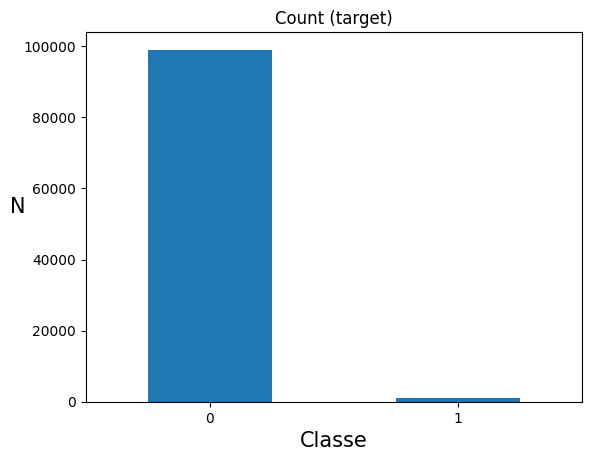

In [10]:
# Génération d'un histogramme des valeurs de la réponse $y$

target_count = df.target.value_counts()
print("Classe 0:", target_count[0])
print("Classe 1:", target_count[1])
print("Proportion:", round(target_count[0] / target_count[1], 4), ": 1")
ax = df.target.value_counts().plot(kind="bar", title="Count (target)", rot=0)
ax.set_xlabel("Classe", fontsize=15)
ax.set_ylabel("N", fontsize=15, rotation=0)

### Le piège des métriques

L'un des principaux problèmes auxquels se heurtent les utilisateurs novices lorsqu'ils traitent des jeux
de données déséquilibrés est lié aux métriques utilisées pour évaluer leur modèle. Utiliser des métriques
plus simples comme l'exactitude peut être trompeur. Dans un ensemble de données avec des
classes très déséquilibrées, si le classificateur "prédit" toujours la classe la plus courante sans
effectuer d'analyse des caractéristiques, il conservera une exactitude élevée, évidemment illusoire.

Faisons cette expérience en utilisant une simple validation croisée sans modifier les caractéristiques. 

> À noter que les principes d'utilisation de la validation croisée sont présentés dans un des modules de la méthodologie.

Dans ce qui suit, on ne normalise pas les données, car elles sont déjà toutes du même ordre de grandeur.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed
)

# Sélection du classificateur
model = SVC(kernel="linear")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

Accuracy: 99.84%


Exécutons maintenant le même code, mais en n'utilisant qu'une seule caractéristique parmi les 20 que contient chaque donnée. Cela devrait considérablement réduire l'exactitude du classificateur puisqu'il y a une grande perte d'information permettant de séparer les nuages de points de chaque classe. Est-ce le cas?

In [12]:
model = SVC(kernel="linear")
model.fit(X_train[:, 0:1], y_train)
y_pred = model.predict(X_test[:, 0:1])

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

Accuracy: 98.96%


Comme nous pouvons le constater, le taux de précision élevé n’était qu’illusion. De cette manière, le choix de la métrique utilisée dans les jeux de données non équilibrés est extrêmement important.

### Techniques de bases en rééchantillonnage

Le rééchantillonnage est une technique largement adoptée pour traiter les jeux de données très déséquilibrés.
Cela consiste à retirer des échantillons de la classe majoritaire (sous-échantillonnage ou
*undersampling*) ou à ajouter d'autres exemples dans la classe minoritaire (suréchantillonnage ou *oversampling*).

<p>&nbsp;</p>
<div align="center">
    <img src= "./images/resampling.png"  width="700" />
    <div>
    <font size="1.5">Image Source: https://www.kaggle.com/code/rafjaa/resampling-strategies-for-imbalanced-datasets/</font>
    </div>
</div>

Malgré l'avantage de l'équilibrage des classes, ces techniques ont aussi leurs faiblesses. La
mise en œuvre la plus simple du suréchantillonnage consiste à dupliquer aléatoirement des données de la
classe minoritaire, ce qui peut entraîner un surapprentissage (*overfitting*). Dans le
sous-échantillonnage, la technique la plus simple consiste à supprimer aléatoirement des enregistrements
de la classe majoritaire, ce qui entraîne nécessairement une perte d'information.

Implémentons un exemple de base, qui utilise la méthode `DataFrame.sample` pour obtenir aléatoirement
des échantillons de chaque classe:

In [13]:
# Nombre de valeurs par classe
count_class_0, count_class_1 = df.target.value_counts()

# Séparation des classes
df_class_0 = df[df["target"] == 0]
df_class_1 = df[df["target"] == 1]

#### Sous-échantillonnage aléatoire

Sous-échantillonnage aléatoire:
target
0    1000
1    1000
Name: count, dtype: int64


Text(0, 0.5, 'N')

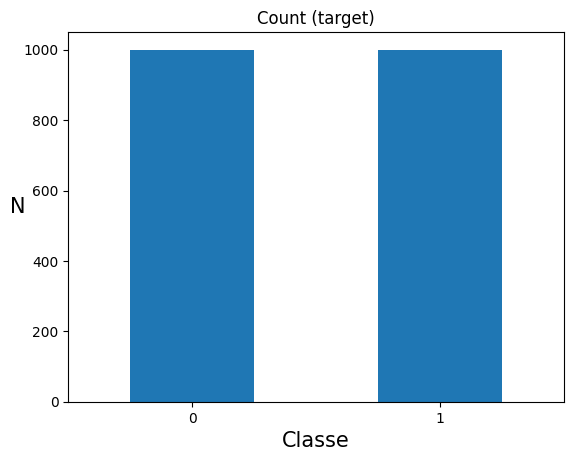

In [14]:
df_class_0_under = df_class_0.sample(count_class_1)
df_test_under = pd.concat([df_class_0_under, df_class_1], axis=0)

print("Sous-échantillonnage aléatoire:")
print(df_test_under.target.value_counts())

ax = df_test_under.target.value_counts().plot(kind="bar", title="Count (target)", rot=0)
ax.set_xlabel("Classe", fontsize=15)
ax.set_ylabel("N", fontsize=15, rotation=0)

#### Suréchantillonnage aléatoire

Suréchantillonnage aléatoire:
target
0    99000
1    99000
Name: count, dtype: int64


Text(0, 0.5, 'N')

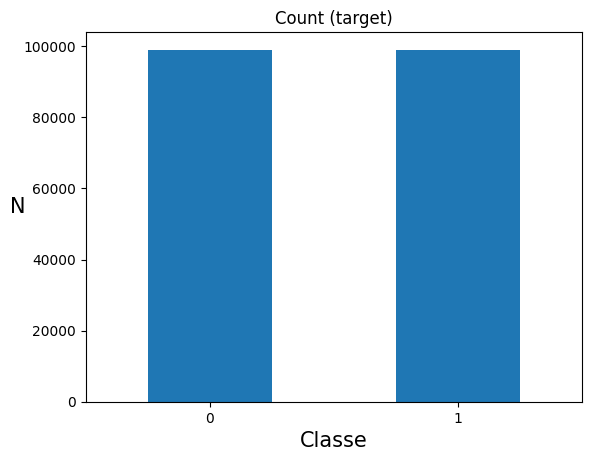

In [15]:
df_class_1_over = df_class_1.sample(count_class_0, replace=True)
df_test_over = pd.concat([df_class_0, df_class_1_over], axis=0)

print("Suréchantillonnage aléatoire:")
print(df_test_over.target.value_counts())

ax = df_test_over.target.value_counts().plot(kind="bar", title="Count (target)", rot=0)
ax.set_xlabel("Classe", fontsize=15)
ax.set_ylabel("N", fontsize=15, rotation=0)

### Techniques plus avancées en rééchantillonnage

Un certain nombre de techniques de rééchantillonnage plus sophistiquées ont été proposées dans la
littérature scientifique.

Par exemple, il est possible de regrouper les données de la classe majoritaire et d'effectuer le
sous-échantillonnage en supprimant des données de chaque regroupement (*cluster*). On préserve
ainsi la distribution multidimensionnelle des données tout en réduisant leur nombre.
En suréchantillonnage, au lieu de créer des copies exactes des données de la classe de minorité,
nous pouvons introduire de petites variations dans ces copies, créant ainsi des échantillons
synthétiques plus divers.

Appliquons certaines de ces techniques de rééchantillonnage en utilisant la librairie Python
[imbalanced-learn](https://imbalanced-learn.org/stable/auto_examples/index.html#general-examples/).
Elle est compatible avec Scikit-learn et fait partie des projets contributeurs de Scikit-learn.

#### Génération d'un nouveau jeu de données

Pour faciliter la visualisation, créons un nouveau jeu de données de taille réduite, toujours avec
deux classes, et ne contenant plus que 100 données $X$ de 20 variables. Cette fois-ci, la répartition
des classes est de ($90~\%$, $10~\%$).

À nouveau, on ne normalise pas les données, car elles sont déjà toutes du même ordre de grandeur.

Text(0, 0.5, 'N')

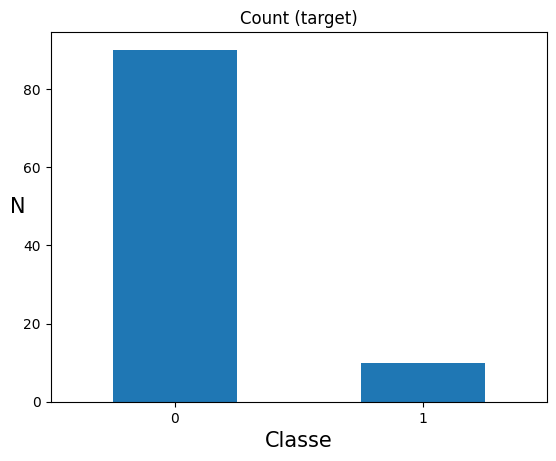

In [16]:
X, y = make_classification(
    n_classes=2,
    class_sep=1.5,
    weights=[0.9, 0.1],
    n_informative=3,
    n_redundant=1,
    flip_y=0,
    n_features=20,
    n_clusters_per_class=1,
    n_samples=100,
    random_state=10,
)

df = pd.DataFrame(X)
df["target"] = y
ax = df.target.value_counts().plot(kind="bar", title="Count (target)", rot=0)
ax.set_xlabel("Classe", fontsize=15)
ax.set_ylabel("N", fontsize=15, rotation=0)

Nous allons également créer une fonction de tracé, <code>plot_2d_space</code>, pour afficher la répartition des données.

In [17]:
def plot_2d_space(X, y, label="Classes"):
    colors = ["#1F77B4", "#FF7F0E"]
    markers = ["o", "s"]
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    for l, c, m in zip(np.unique(y), colors, markers):
        plt.scatter(X[y == l, 0], X[y == l, 1], c=c, label=l, marker=m, alpha=0.5)
    ax.set_xlabel("$PC_{1}$", fontsize=15)
    ax.set_ylabel("$PC_{2}$", fontsize=15)
    plt.title(label)
    plt.legend(loc="upper right")
    plt.show()

Étant donné que le jeu de données est en 20-D et que nos graphiques seront en 2-D, la taille du jeu de données est
réduite au moyen de l'analyse en composantes principales (*PCA*). On n'utilise que les deux
premières composantes principales.

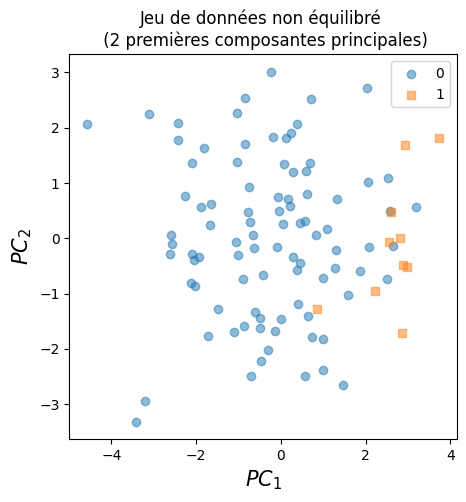

In [18]:
pca = PCA(n_components=2)
X = pca.fit_transform(X)

plot_2d_space(
    X,
    y,
    "Jeu de données non équilibré \n (\
2 premières composantes principales)",
)

#### Sous-échantillonnage aléatoire avec apprentissage déséquilibré

Réduire le nombre de données de la classe majoritaire n'est pas une bonne option dans cet exemple, car il ne reste que peu de données à utiliser par la suite.

Indices retirés : [39 48 87 62 93 54 36 86  7 37  4  8  9 14 16 40 67 70 71 74]


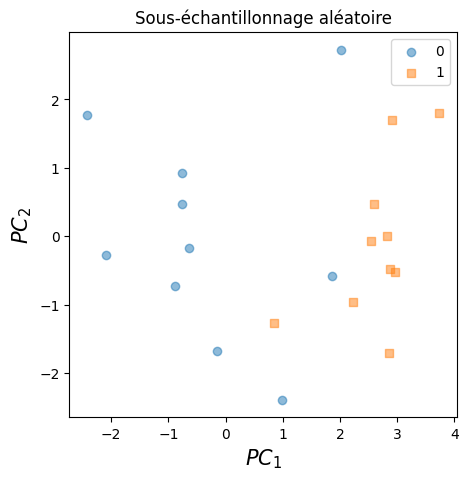

In [19]:
rus = RandomUnderSampler()
X_rus, y_rus = rus.fit_resample(X, y)
id_rus = rus.sample_indices_

print("Indices retirés :", id_rus)

plot_2d_space(X_rus, y_rus, "Sous-échantillonnage aléatoire")

#### Suréchantillonnage aléatoire avec apprentissage déséquilibré

Augmenter le nombre de données de la classe minoritaires n'est pas une bonne option dans cet exemple, car il y a trop peu de données différentes.

80 nouveaux points aléatoires


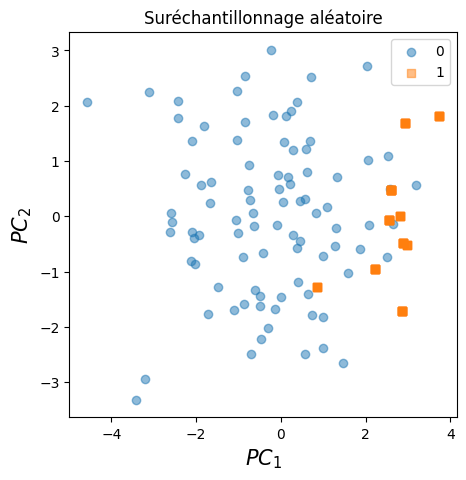

In [20]:
ros = RandomOverSampler()
X_ros, y_ros = ros.fit_resample(X, y)

print(X_ros.shape[0] - X.shape[0], "nouveaux points aléatoires")

plot_2d_space(X_ros, y_ros, "Suréchantillonnage aléatoire")

#### Sous-échantillonnage avec liens Tomek

Les liens Tomek sont des paires d'instances très proches, mais de classes opposées. La suppression des occurrences de la classe majoritaire de chaque paire augmente l'espace entre les deux classes, facilitant ainsi le processus de classification.

<p>&nbsp;</p>
<div align="center">
    <img src= "./images/tomek.png"  width="800" />
    <div>
    <font size="1.5">Image Source: https://www.kaggle.com/code/rafjaa/resampling-strategies-for-imbalanced-datasets/</font>
    </div>
</div>

Dans le code ci-dessous, nous utiliserons `sampling_strategy = 'majority'` pour rééchantillonner la classe majoritaire.

Indices retirés: [ 0  1  2  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73
 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 90 91 92 93 94 95 97 98 99]


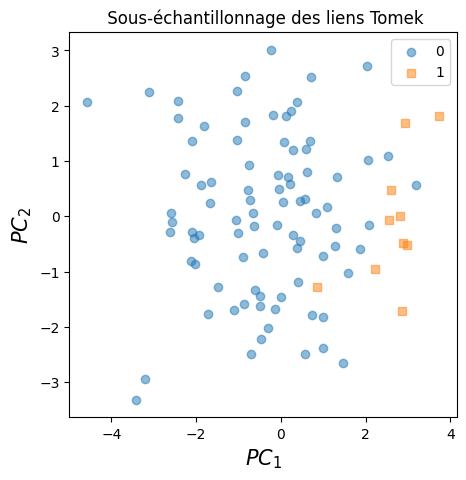

In [21]:
tl = TomekLinks(sampling_strategy="majority")
X_tl, y_tl = tl.fit_resample(X, y)
id_tl = tl.sample_indices_

print("Indices retirés:", id_tl)

plot_2d_space(X_tl, y_tl, " Sous-échantillonnage des liens Tomek")

#### Suréchantillonnage avec SMOTE

SMOTE (*synthetic minority oversampling technique*) consiste à synthétiser des éléments pour
la classe minoritaire, sur la base de ceux qui existent déjà. Cela fonctionne de manière aléatoire
en sélectionnant un point de la classe minoritaire et en calculant les k-voisins les plus proches
pour ce point (k-NN). Les points synthétiques sont ajoutés entre le point choisi et ses voisins.

<p>&nbsp;</p>
<div align="center">
    <img src= "./images/smote.png"  width="800" />
    <div>
    <font size="1.5">Image Source: https://www.kaggle.com/code/rafjaa/resampling-strategies-for-imbalanced-datasets/</font>
    </div>
</div>

Nous allons utiliser `sampling_strategy = 'minority'` pour rééchantillonner la classe minoritaire.

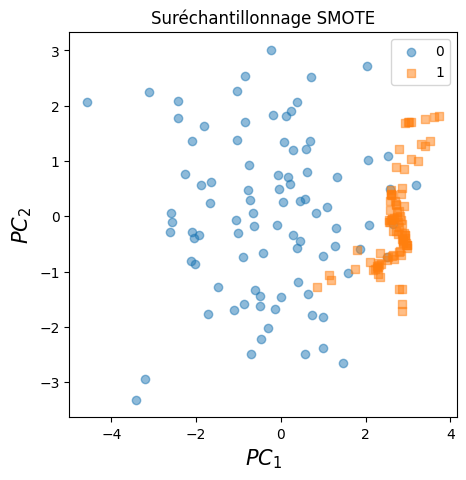

In [22]:
smote = SMOTE(sampling_strategy="minority")
X_sm, y_sm = smote.fit_resample(X, y)

plot_2d_space(X_sm, y_sm, "Suréchantillonnage SMOTE")

#### Suréchantillonnage suivi d'un sous-échantillonnage

Nous pouvons maintenant combiner le suréchantillonnage et le sous-échantillonnage, en utilisant les techniques de liens SMOTE et Tomek.

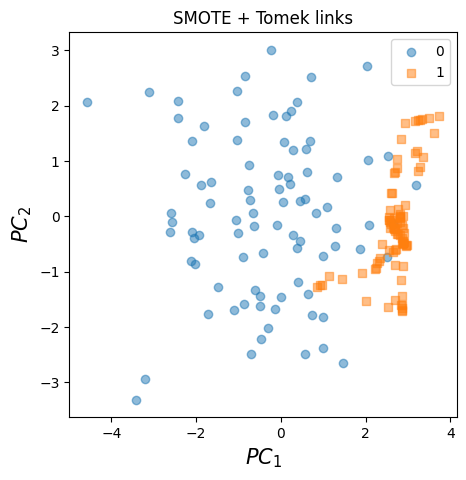

In [23]:
smt = SMOTETomek(sampling_strategy="auto")
X_smt, y_smt = smt.fit_resample(X, y)

plot_2d_space(X_smt, y_smt, "SMOTE + Tomek links")

## Pour en savoir plus

- [Documentation](https://imbalanced-learn.org/stable/user_guide.html) de la librairie *imbalanced-learn*:
- [Chawla, Nitesh V., et al. "SMOTE: synthetic minority over-sampling technique." Journal of artificial intelligence research 16 (2002)](http://export.arxiv.org/pdf/1106.1813)
- https://www.kaggle.com/code/rafjaa/resampling-strategies-for-imbalanced-datasets/